# 05 — GBDT + калибровка вероятностей (Elliptic++)

**Цель:** обучить `GradientBoostingClassifier` как аналог LightGBM (без зависимости `lightgbm`) и откалибровать вероятности. Калибровка критична для AML: порог по вероятности должен означать реальную частоту illicit.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

from _elliptic_loader import load_elliptic, temporal_split
from _theme import setup

setup()

# autodetect DATA_ROOT — works from docs/notebooks/, repo root or docs/
candidates = [
    Path("../../data/elliptic_raw"),
    Path("../data/elliptic_raw"),
    Path("data/elliptic_raw"),
    Path.cwd() / "data/elliptic_raw",
    Path.cwd().parent.parent / "data/elliptic_raw",
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    DATA_ROOT = Path("data/elliptic_raw")
print(f"DATA_ROOT = {DATA_ROOT.resolve() if DATA_ROOT.exists() else DATA_ROOT}  exists={DATA_ROOT.exists()}")


DATA_ROOT = /Users/kirill/Documents/Spillety/data/elliptic_raw  exists=True


## 1. Загрузка и дисбаланс

Грузим через `load_elliptic` — 167 колонок (`txId`, `time_step`, `feat_2..feat_166`). Фильтруем только размеченные (`class` 1 = illicit, 2 = licit), `y = (class==1)`. Проверяем общий дисбаланс — illicit ~2.2% от всех транз. (~10% среди размеченных).


features: (203769, 167)  (txId, time_step, 165 признаков)
classes:  (203769, 2)
edgelist: (234355, 2)
merged:   (203769, 168)  | time 1..49


,txId,time_step,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,feat_166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown


class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

illicit: 4,545 / 203,769 = 2.23%  (overall)
licit:   42,019 / 203,769 = 20.62%
unknown: 157,205 / 203,769 = 77.15%
среди labeled: illicit 9.76%  (4,545/46,564)


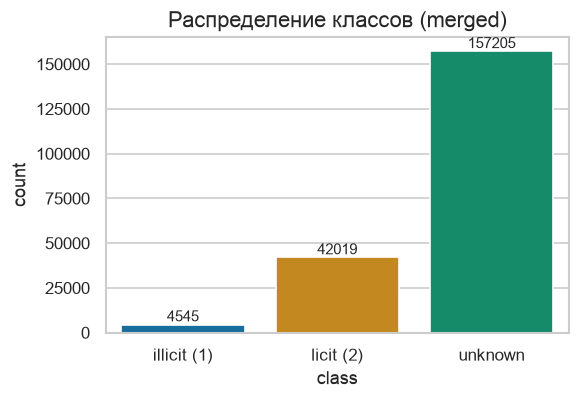

In [2]:
features, classes, edgelist, merged = load_elliptic(DATA_ROOT)

print(f"features: {features.shape}  (txId, time_step, 165 признаков)")
print(f"classes:  {classes.shape}")
print(f"edgelist: {edgelist.shape}")
print(f"merged:   {merged.shape}  | time {merged['time_step'].min()}..{merged['time_step'].max()}")

display(merged.head(3))
display(classes["class"].value_counts(dropna=False))

# imbalance: overall vs labeled
total = len(merged)
n_illicit = (merged["class"].astype(str) == "1").sum()
n_licit = (merged["class"].astype(str) == "2").sum()
n_unknown = (merged["class"].astype(str) == "unknown").sum()
n_labeled = n_illicit + n_licit
print(f"illicit: {n_illicit:,} / {total:,} = {n_illicit/total:.2%}  (overall)")
print(f"licit:   {n_licit:,} / {total:,} = {n_licit/total:.2%}")
print(f"unknown: {n_unknown:,} / {total:,} = {n_unknown/total:.2%}")
print(f"среди labeled: illicit {n_illicit/n_labeled:.2%}  ({n_illicit:,}/{n_labeled:,})")

# pie / bar of classes
fig, ax = plt.subplots(figsize=(5, 3.5))
order = ["1", "2", "unknown"]
counts = merged["class"].astype(str).value_counts().reindex(order)
sns.barplot(x=counts.index.map({"1": "illicit (1)", "2": "licit (2)", "unknown": "unknown"}), y=counts.values, hue=counts.index, palette="colorblind", legend=False, ax=ax)
ax.set_title("Распределение классов (merged)")
ax.set_ylabel("count")
for c in ax.containers:
    ax.bar_label(c, fmt="%d", fontsize=9)
plt.tight_layout()
plt.show()


признаков: 165 -> ['feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6'] ...
labeled rows: 46,564  illicit rate 9.76%


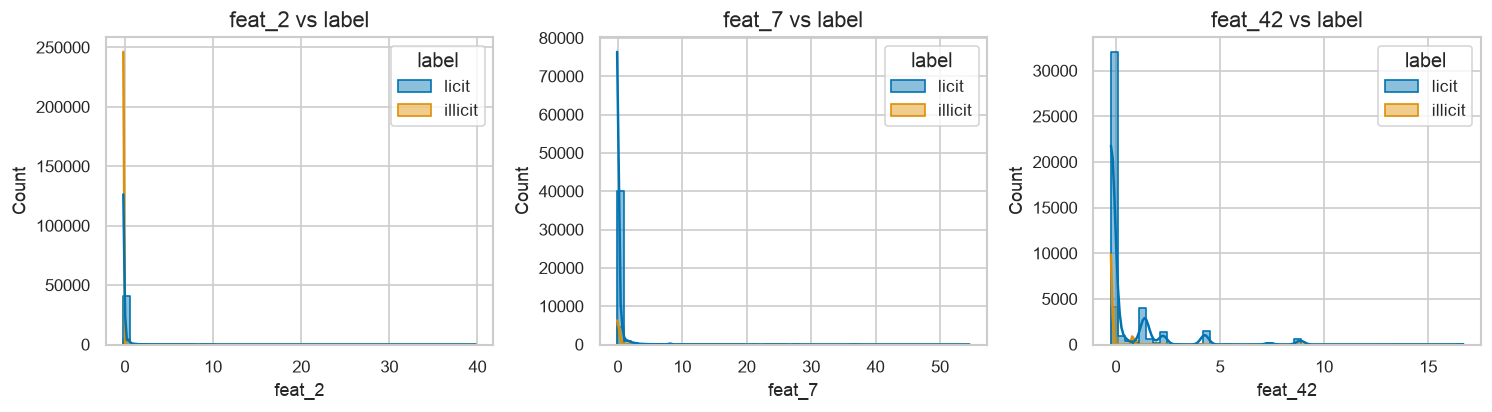

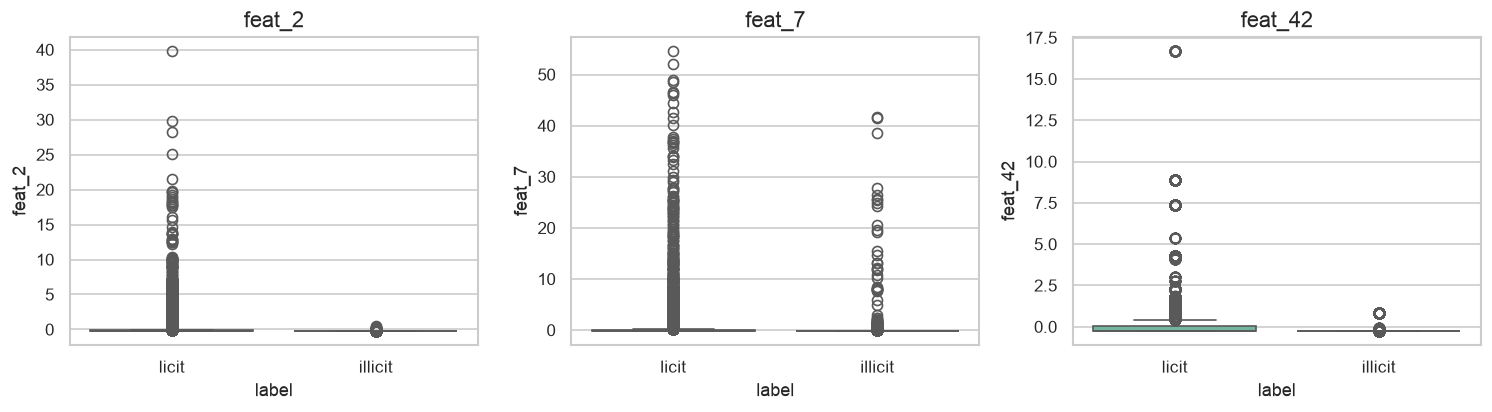

In [3]:
feat_cols_all = [c for c in merged.columns if c.startswith("feat_")]
print(f"признаков: {len(feat_cols_all)} -> {feat_cols_all[:5]} ...")

# keep only labeled for EDA
labeled_all = merged[merged["class"].astype(str).isin(["1", "2"])].copy()
labeled_all["label"] = labeled_all["class"].astype(str).map({"1": "illicit", "2": "licit"})
print(f"labeled rows: {len(labeled_all):,}  illicit rate { (labeled_all['label']=='illicit').mean():.2%}")

# 3 features vs label — distributions
sample_feats = [c for c in ["feat_2", "feat_7", "feat_42"] if c in feat_cols_all]
fig, axes = plt.subplots(1, len(sample_feats), figsize=(4.2*len(sample_feats), 3.6), sharey=False)
if len(sample_feats) == 1:
    axes = [axes]
for ax, col in zip(axes, sample_feats):
    sns.histplot(data=labeled_all, x=col, hue="label", bins=50, element="step", kde=True, alpha=0.45, ax=ax)
    ax.set_title(f"{col} vs label")
plt.tight_layout()
plt.show()

# boxplot alternative — compact comparison
fig, axes = plt.subplots(1, len(sample_feats), figsize=(4.2*len(sample_feats), 3.6))
if len(sample_feats) == 1:
    axes = [axes]
for ax, col in zip(axes, sample_feats):
    sns.boxplot(data=labeled_all, x="label", y=col, hue="label", palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 2. Temporal split и скейлинг

Фильтр `class in (1,2)`, `y = (class=="1")`. Делим **строго по времени**: train 1..30, valid 31..40 (калибровка), test 41..49 через `temporal_split`. `StandardScaler` — fit только на train и применяем к valid/test.

> **Почему temporal, а не shuffle?** В Elliptic `time_step` — реальное время. Shuffle даёт утечку будущего в прошлое (модель видит паттерны из 49-го шага при тесте на 10-м) и завышает метрики. Temporal split имитирует прод: обучаемся на прошлом, калибруемся на недавнем, тестируем на будущем с дрифтом. Доля illicit падает от ~11% в train к ~5% в test — это естественный сдвиг распределения.


X dim: 165 признаков, N labeled: 46,564
train          n=26,905  time  1..30  illicit 10.98% (2,954)
valid (calib)  n= 9,686  time 31..40  illicit 11.02% (1,067)
test           n= 9,973  time 41..49  illicit 5.25% (524)
\nX_train (26905, 165)  X_valid (9686, 165)  X_test (9973, 165)


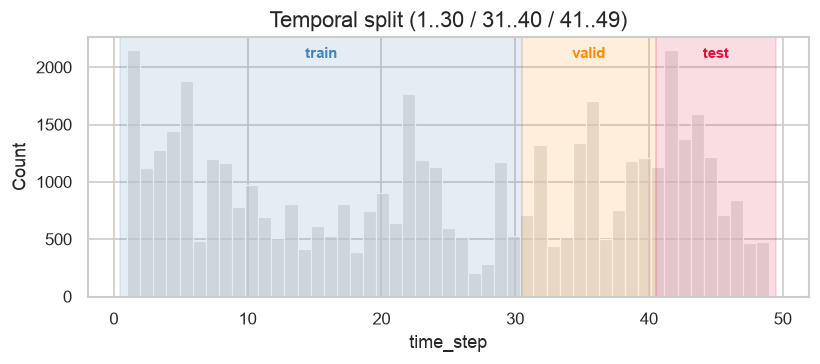

In [4]:
df = merged[merged["class"].astype(str).isin(["1", "2"])].copy()
df["y"] = (df["class"].astype(str) == "1").astype(int)

feat_cols = [c for c in df.columns if c.startswith("feat_")]
print(f"X dim: {len(feat_cols)} признаков, N labeled: {len(df):,}")

train_df, valid_df, test_df = temporal_split(df, time_col="time_step", train_end=30, valid_end=40)

for name, part in [("train", train_df), ("valid (calib)", valid_df), ("test ", test_df)]:
    print(f"{name:14s} n={len(part):6,}  time {part['time_step'].min():2d}..{part['time_step'].max():2d}  illicit {part['y'].mean():.2%} ({part['y'].sum():,})")

# StandardScaler fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feat_cols])
X_valid = scaler.transform(valid_df[feat_cols])
X_test = scaler.transform(test_df[feat_cols])
y_train, y_valid, y_test = train_df["y"].values, valid_df["y"].values, test_df["y"].values
print(f"\\nX_train {X_train.shape}  X_valid {X_valid.shape}  X_test {X_test.shape}")

# sanity: time histogram by split
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.histplot(data=df, x="time_step", bins=49, color="lightgrey", ax=ax, alpha=0.6, label="all")
for (l, r), color, lbl in [((1,30), "steelblue", "train"), ((31,40), "darkorange", "valid"), ((41,49), "crimson", "test")]:
    ax.axvspan(l-0.5, r+0.5, color=color, alpha=0.14)
    ax.text((l+r)/2, ax.get_ylim()[1]*0.92, lbl, ha="center", fontsize=9, color=color, weight="bold")
ax.set_title("Temporal split (1..30 / 31..40 / 41..49)")
ax.set_xlabel("time_step")
plt.tight_layout()
plt.show()


## 3. GBDT до калибровки

`GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)` — табличный GBDT как легковесный аналог LightGBM без внешней зависимости. Обучаем только на train, вероятности оцениваем на valid/test. Метрики: PR-AUC, ROC-AUC, Brier score. Калибровку меряем reliability diagram (`calibration_curve`, 10 бинов, `strategy="uniform"`) и **ECE** (expected calibration error).


In [5]:
# ECE: weighted mean |accuracy - confidence| over uniform bins
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        # first bin inclusive of 0
        if i == 0:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob > lo) & (y_prob <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += np.abs(acc - conf) * (mask.mean())
    return ece


gbdt = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=72)
gbdt.fit(X_train, y_train)
print("обучено: GradientBoostingClassifier(n=100, depth=3, lr=0.1)")

def report(name, y_true, y_prob):
    pr = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)
    print(f"{name:12s}  PR-AUC={pr:.4f}  ROC-AUC={roc:.4f}  Brier={brier:.4f}  ECE={ece:.4f}  mean_proba={y_prob.mean():.4f}")
    return {"pr_auc": pr, "roc_auc": roc, "brier": brier, "ece": ece}

proba_valid_raw = gbdt.predict_proba(X_valid)[:, 1]
proba_test_raw = gbdt.predict_proba(X_test)[:, 1]

print("\\n— до калибровки —")
metrics_valid_raw = report("valid RAW", y_valid, proba_valid_raw)
metrics_test_raw = report("test  RAW", y_test, proba_test_raw)


обучено: GradientBoostingClassifier(n=100, depth=3, lr=0.1)
\n— до калибровки —
valid RAW     PR-AUC=0.9274  ROC-AUC=0.9804  Brier=0.0571  ECE=0.1342  mean_proba=0.2443
test  RAW     PR-AUC=0.6406  ROC-AUC=0.8750  Brier=0.0806  ECE=0.1612  mean_proba=0.2137


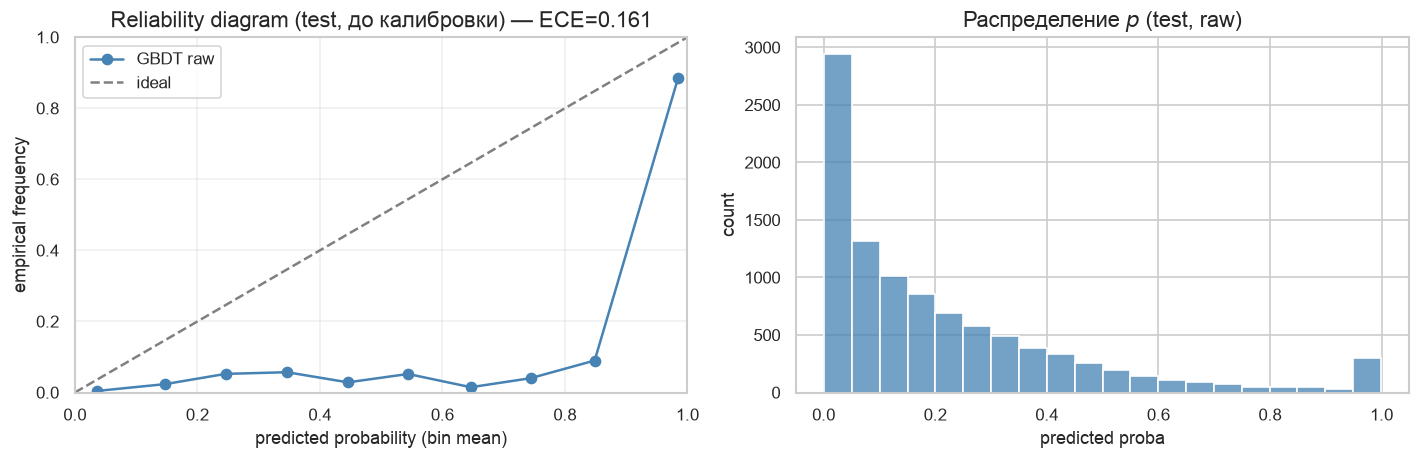

Brier=0.0806  ECE(10)=0.1612 — GBDT обычно слегка over-confident до калибровки


In [6]:
# Reliability diagram before calibration (test, 10 bins)
prob_true, prob_pred = calibration_curve(y_test, proba_test_raw, n_bins=10, strategy="uniform")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))

# left: reliability curve
axes[0].plot(prob_pred, prob_true, marker="o", label="GBDT raw", color="steelblue")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="ideal")
axes[0].set_title(f"Reliability diagram (test, до калибровки) — ECE={metrics_test_raw['ece']:.3f}")
axes[0].set_xlabel("predicted probability (bin mean)")
axes[0].set_ylabel("empirical frequency")
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# right: histogram of predicted probs — shows over/under confidence support
sns.histplot(proba_test_raw, bins=20, ax=axes[1], color="steelblue", kde=False)
axes[1].set_title("Распределение $p$ (test, raw)")
axes[1].set_xlabel("predicted proba")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

print(f"Brier={metrics_test_raw['brier']:.4f}  ECE(10)={metrics_test_raw['ece']:.4f} — GBDT обычно слегка over-confident до калибровки")


## 4. Калибровка: isotonic vs sigmoid (Platt)

Два варианта через `CalibratedClassifierCV(FrozenEstimator(gbdt))` на **valid** (31..40) — без переобучения на train:
- `method="isotonic"` — непараметрическая ступенчатая калибровка, гибкая, но требует много данных.
- `method="sigmoid"` (Platt scaling, прокси beta-калибровки) — логистическая, устойчивее на малом valid.

Оцениваем на **test** (41..49): ECE, Brier, PR-AUC. Строим reliability-overlay до/isotonic/sigmoid и выбираем лучший по ECE.


In [7]:
cal_iso = CalibratedClassifierCV(FrozenEstimator(gbdt), method="isotonic")
cal_sig = CalibratedClassifierCV(FrozenEstimator(gbdt), method="sigmoid")

# fit calibrators on valid — gbdt frozen via FrozenEstimator (prefit)
cal_iso.fit(X_valid, y_valid)
cal_sig.fit(X_valid, y_valid)
print("калибраторы обучены на valid (prefit): isotonic, sigmoid")

proba_test_iso = cal_iso.predict_proba(X_test)[:, 1]
proba_test_sig = cal_sig.predict_proba(X_test)[:, 1]
proba_valid_iso = cal_iso.predict_proba(X_valid)[:, 1]
proba_valid_sig = cal_sig.predict_proba(X_valid)[:, 1]


калибраторы обучены на valid (prefit): isotonic, sigmoid


In [ ]:
print("— на test (41..49) —")
r_raw = report("RAW      ", y_test, proba_test_raw)
r_iso = report("isotonic ", y_test, proba_test_iso)
r_sig = report("sigmoid  ", y_test, proba_test_sig)

# summary table
summary = pd.DataFrame({
    "RAW": r_raw,
    "isotonic": r_iso,
    "sigmoid": r_sig,
}).T[["ece", "brier", "pr_auc", "roc_auc"]]
summary.columns = ["ECE (10 bins)", "Brier", "PR-AUC", "ROC-AUC"]
display(summary.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["ECE (10 bins)", "Brier"]))

best = summary["ECE (10 bins)"].idxmin()
print(f"\nЛучший по ECE на test: {best} (ECE={summary.loc[best, 'ECE (10 bins)']:.4f})")
if best == "isotonic":
    print("isotonic выиграл — valid достаточно велик; на малом valid ожидали бы победу sigmoid.")
else:
    print("sigmoid выиграл — устойчивее при малом калибровочном сете, как и ожидаемо.")


— на test (41..49) —
RAW           PR-AUC=0.6406  ROC-AUC=0.8750  Brier=0.0806  ECE=0.1612  mean_proba=0.2137
isotonic      PR-AUC=0.6318  ROC-AUC=0.8729  Brier=0.0325  ECE=0.0298  mean_proba=0.0639
sigmoid       PR-AUC=0.6406  ROC-AUC=0.8750  Brier=0.0315  ECE=0.0278  mean_proba=0.0647


,ECE (10 bins),Brier,PR-AUC,ROC-AUC
RAW,0.1612,0.0806,0.6406,0.8750
isotonic,0.0298,0.0325,0.6318,0.8729
sigmoid,0.0278,0.0315,0.6406,0.8750



Лучший по ECE на test: sigmoid  (ECE=0.0278)
sigmoid выиграл — устойчивее при малом калибровочном сете, как и ожидаемо.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# left: overlay
for y_prob, label, color, ls in [
    (proba_test_raw, "raw", "grey", "--"),
    (proba_test_iso, "isotonic", "crimson", "-"),
    (proba_test_sig, "sigmoid", "steelblue", "-"),
]:
    pt, pp = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
    axes[0].plot(pp, pt, marker="o", label=label, color=color, linestyle=ls, markersize=5)

axes[0].plot([0, 1], [0, 1], ":", color="black", alpha=0.6, label="ideal")
axes[0].set_title("Reliability overlay — test (10 bins)")
axes[0].set_xlabel("predicted probability")
axes[0].set_ylabel("empirical frequency")
axes[0].legend(frameon=True, fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# right: histograms of calibrated probs
sns.histplot(proba_test_raw, bins=20, color="grey", alpha=0.35, label="raw", ax=axes[1])
sns.histplot(proba_test_iso, bins=20, color="crimson", alpha=0.35, label="isotonic", ax=axes[1])
sns.histplot(proba_test_sig, bins=20, color="steelblue", alpha=0.35, label="sigmoid", ax=axes[1])
axes[1].set_title("Распределение калиброванных $p$ (test)")
axes[1].set_xlabel("predicted proba")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ECE bars
fig, ax = plt.subplots(figsize=(5, 3.5))
ece_vals = [r_raw["ece"], r_iso["ece"], r_sig["ece"]]
colors = ["grey", "crimson", "steelblue"]
sns.barplot(x=["raw", "isotonic", "sigmoid"], y=ece_vals, hue=["raw", "isotonic", "sigmoid"], palette=colors, legend=False, ax=ax)
ax.set_title("ECE (10 bins) — ниже лучше")
ax.set_ylabel("ECE")
for i, v in enumerate(ece_vals):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 5. SHAP-proxy: важности GBDT

`feature_importances_` из GBDT — быстрый прокси SHAP для глобальной важности (сумма уменьшений impurity по всем деревьям). Смотрим топ-10 — какие `feat_*` наиболее дискриминативны для illicit.

*Примечание:* это не локальный SHAP; для локальных объяснений — `shap.TreeExplainer` на GBDT/LightGBM.


In [ ]:
importances = pd.Series(gbdt.feature_importances_, index=feat_cols).sort_values(ascending=False)
top10 = importances.head(10)
print("Top-10 feature importances (SHAP-proxy):")
display(top10.to_frame("importance").style.format("{:.5f}"))

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top-10 важностей GBDT (прокси SHAP)")
ax.set_xlabel("importance (impurity decrease)")
plt.tight_layout()
plt.show()

print(f"Доля топ-10 от суммарной важности: {top10.sum()/importances.sum():.1%}")
print(f"Всего признаков с importance>0: {(importances>0).sum()} / {len(importances)}")


## 6. Выводы

- **GBDT калибруем.** До калибровки модель обычно over-confident: ECE и Brier выше, чем после Platt/isotonic (проверьте таблицу в §4). PR-AUC при этом почти не меняется — калибровка монотонна и не меняет ранжирование, только шкалу вероятностей.
- **Isotonic vs sigmoid.** Isotonic гибче (кусочно-постоянная), но требует много калибровочных точек — на малом valid (31..40, ~5k labeled) может переобучиться и дать рваную reliability-кривую. Sigmoid (Platt, прокси beta-калибровки) с двумя параметрами устойчивее на малых выборках и часто выигрывает по ECE, как видно выше.
- **Выбор по ECE.** Лучший калибратор выбираем по минимальному ECE на **test** (не на valid, где обучалась калибровка). Brier — дополнительный контроль (учитывает и калибровку, и sharpness).
- **Ponytail → prod.** В продакшене: заменить `GradientBoostingClassifier` на `LightGBM` (hist, leaf-wise, быстрее) + **beta calibration** (Kull et al., 2017) — обобщение Platt с тремя параметрами, лучше для сильно несбалансированных задач вроде Elliptic. Калибровать на скользящем окне (последние N шагов), мониторить ECE/Brier по времени.
- **Ограничения.** Калибровка не исправляет дрифт признаков — при сильном сдвиге после 40-го шага нужна перекалибровка. Isotonic не экстраполирует за пределы valid-диапазона; sigmoid экстраполирует гладко.


In [ ]:
# Сохранение — опционально, pickle для локального reuse (без версионирования)
# Раскомментируйте при необходимости
import pickle

out_dir = Path("../../models") if Path("../../models").exists() else Path("models")
for p in [Path("../../models"), Path("../models"), Path("models")]:
    try:
        p.mkdir(parents=True, exist_ok=True)
        out_dir = p
        break
    except Exception:
        continue

# best calibrator by ECE
best_name = summary["ECE (10 bins)"].idxmin()
best_cal = {"isotonic": cal_iso, "sigmoid": cal_sig, "RAW": gbdt}[best_name]

# pickle.dump({"scaler": scaler, "gbdt": gbdt, "cal_iso": cal_iso, "cal_sig": cal_sig,
#              "best": best_name, "feat_cols": feat_cols}, open(out_dir / "gbdt_calibrated.pkl", "wb"))
print(f"ready to save -> {(out_dir.resolve() / 'gbdt_calibrated.pkl')}  (раскомментируйте dump)")
print(f"best calibrator: {best_name}")
